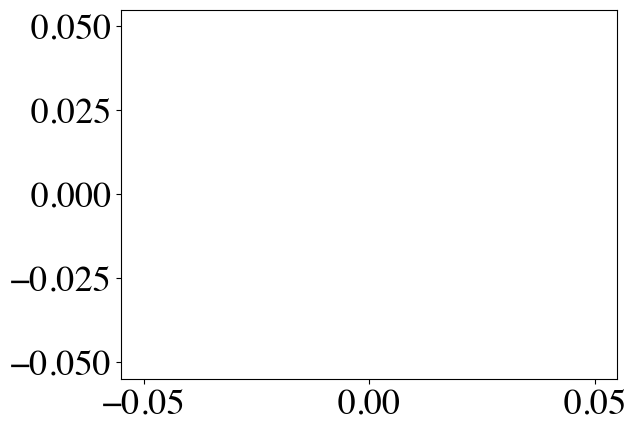

In [68]:
####### Imports and plotting utils definitions
## Modified from https://github.com/Chuneeta/beam_solver/blob/master/beam_solver/fits_utils.py

import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy import wcs
from astropy.cosmology import LambdaCDM
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
import aplpy
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import colors
from colormaps import spectral
from matplotlib.colors import ColorConverter
import warnings
from astropy.coordinates import AltAz, EarthLocation, SkyCoord
from astropy.time import Time
from astropy import units as u
from reproject import reproject_from_healpix
import glob
import healpy as hp
import os
import scipy
import pylab as pl
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from scipy import optimize
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

# Font properties
# Note: TNR required for bolding due to font manager bug
# Math font for compact, times-like scientific notation
# Exit out of notebook before changing
times_font=True
if times_font:
    font_bold = fm.FontProperties(family='Times New Roman', style='normal', size=32, weight='bold', stretch='normal')
    font      = fm.FontProperties(family='Times', style='normal', size=14, weight='normal', stretch='normal')
    font_name ='Times'
    plt.rcParams["mathtext.fontset"] = "stixsans"
    plt.rcParams['font.family'] = 'Times'
else:
    font_name ='Dejavu Sans'
    font_bold = fm.FontProperties(family='Dejavu Sans', style='normal', size=14, weight='bold', stretch='normal')
    font      = fm.FontProperties(family='Dejavu Sans', style='normal', size=14, weight='normal', stretch='normal')  

# Set defaults for plot font and size
matplotlib.rc('font', size=26)
matplotlib.rc('axes', labelsize=26)    
    
# Color map
cb_spec, cb_spec_r = spectral()
cb_spec.set_bad('white')

# Colorbar
colorbar_scale_catalog = plt.pcolor([0,0], [0,0], [[0,0],[0,0]] ,norm=colors.Normalize(vmin=0, vmax=6000),
            cmap=cb_spec)#'Spectral_r')
colorbar_scale_nobeam = plt.pcolor([0,0], [0,0], [[0,0],[0,0]] ,norm=colors.Normalize(vmin=-6000, vmax=6000),
            cmap=cb_spec)#'Spectral_r')
colorbar_scale_inst = plt.pcolor([0,0], [0,0], [[0,0],[0,0]] ,norm=colors.Normalize(vmin=-50, vmax=50),
            cmap=cb_spec)#'Spectral_r')
colorbar_scale_data = plt.pcolor([0,0], [0,0], [[0,0],[0,0]] ,norm=colors.Normalize(vmin=-100, vmax=100),
            cmap=cb_spec)#'Spectral_r')

## Plotting parameters for colors and plot locations
# Spectral custom colors
ColorConverter.colors['e']=(94/256, 79/256, 162/256)
ColorConverter.colors['g']=(50/256, 136/256, 189/256)
ColorConverter.colors['h']=(102/256, 194/256, 165/256)
ColorConverter.colors['i']=(253/256, 174/256, 97/256) 
ColorConverter.colors['j']=(219/256, 55/256, 82/256)
    
# Utilities
def str_to_pixel(fitsfile):
    """
    Changes the units from the FHD standard of Jy/str to Jy/pixel given 
    the typical pixel size of a 2048x2048 full sky uv-plane
    """
    my_cosmo = LambdaCDM(67.8, 0.308, 0.692)
    str_to_pixel = (0.0559529*(np.pi/180))**2   
    str_to_beam = 2.1614375e-06
    data, hdr = fits.getdata(fitsfile, header=True)
    # Set missing data to nans to become white
    data[data==0] = np.nan
    fits.writeto(fitsfile.replace('.fits','.beam.fits'),\
        data[:,:]*str_to_pixel*1000., header=hdr, overwrite=True)
    
    return fitsfile.replace('.fits','.beam.fits')

def percentratio(fitsfile1,fitsfile2):
    """
    Create a percent ratio image and save with appropriate header
    """
    data1, hdr1 = fits.getdata(fitsfile1, header=True)
    # Set missing data to nans to become white
    data1[data1==0] = np.nan
    data2, hdr2 = fits.getdata(fitsfile2, header=True)
    # Set missing data to nans to become white
    data2[data2==0] = np.nan
    data = np.abs(((data1 - data2) / data1) * 100.0)
    fits.writeto(fitsfile1.replace('.fits','.percentratio.fits'),\
        data[:,:], header=hdr1, overwrite=True)
    
    return fitsfile1.replace('.fits','.percentratio.fits')

def fitsdiff(fitsfile1,fitsfile2):
    """
    Create a difference image and save with appropriate header
    """
    data1, hdr1 = fits.getdata(fitsfile1, header=True)
    # Set missing data to nans to become white
    data1[data1==0] = np.nan
    data2, hdr2 = fits.getdata(fitsfile2, header=True)
    # Set missing data to nans to become white
    data2[data2==0] = np.nan
    data = data1 - data2
    fits.writeto(fitsfile1.replace('.fits','.diff.fits'),\
        data[:,:], header=hdr1, overwrite=True)
    
    return fitsfile1.replace('.fits','.diff.fits')

def get_fitsinfo(fitsfile):
    """
    Extracts data and header information (metadata) from fits file
    fitsfile: Input fitsfile
    """
    data, hdr = fits.getdata(fitsfile, header=True)
    data = data.squeeze()
    freq = 182. #hdr ['CRVAL3']
    #nxaxis = hdr['NAXIS1']
    #nyaxis = hdr['NAXIS2']
    return {'data':data, 'hdr':hdr, 'freq':freq} #, 'nxaxis':nxaxis, 'nyaxis':nyaxis}

def del_keyword(fitsfile, key, outfits, overwrite=False):
    """
    Deleting keyword from the header of the fitsfile
    fitsfile: Input fitsfile
    key: Keyword to be added to the header
    outfits: Output fitsfile.
    overwrite: Overwrites any exisiting file. Default is False.
    """
    _info = get_fitsinfo(fitsfile)
    hdr = _info['hdr']
    assert key in hdr.keys(), "given key not present in the header"
    del hdr[key]
    fits.writeto(outfits, _info['data'], hdr, overwrite=overwrite)
    
def add_keyword(fitsfile, key, value, outfits, overwrite=False):
    """
    Adding a keyword to the header of the fitsfile
    fitsfile: Input fitsfile
    key: Keyword to be added to the header
    value: Value of the keyword
    outfits: Output fitsfile.
    overwrite: Overwrites any exisiting file. Default is False.
    """
    _info = get_fitsinfo(fitsfile)
    hdr = _info['hdr']
    hdr.append(key)
    hdr[key] = value
    fits.writeto(outfits, _info['data'], hdr, overwrite=overwrite)
    
def get_radec(fitsfile):
    _info = get_fitsinfo(fitsfile)
    hdr= _info['hdr']
    
    naxis1 = hdr['NAXIS1']
    naxis2 = hdr['NAXIS2']
    x = np.linspace(1, naxis1, naxis1)
    y = np.linspace(1, naxis2, naxis2)
    xx, yy = np.meshgrid(x, y)
    
    ### vstack: Stack arrays in sequence vertically (row wise).
    ## a = np.array([1, 2, 3])
    ## b = np.array([4, 5, 6])
    ## np.vstack((a,b))
    ## array([[1, 2, 3],
    ##       [4, 5, 6]])
    ### T: transpose
    ### reshape(-1): reshape to one dimension
    pixargs = np.vstack([xx.reshape(-1), yy.reshape(-1)]).T
    
    wcs = WCS(fitsfile)
    
    if wcs.has_spectral:
        freq = np.copy(xx.reshape(-1))
        freq[:] = 1
        pixargs = np.vstack([xx.reshape(-1), yy.reshape(-1), freq, freq]).T
        world = wcs.all_pix2world(pixargs, 1)
    else:
        pixargs = np.vstack([xx.reshape(-1), yy.reshape(-1)]).T
        world = wcs.all_pix2world(pixargs, 1)
    
    ra = world[:,0].reshape(naxis1,naxis1)
    dec = world[:,1].reshape(naxis1,naxis1)
    
    return ra, dec

def find_horizon(fitsfile):
    """
    Find the horizon in RA DEC for an observation so that it can be plotted
    """
    _info = get_fitsinfo(fitsfile)
    hdr = _info['hdr']
    
    mwa_alt = 377.827 #(MWA, from Tingay et al. 2013)#
    mwa_lat = -26.7033194 #(MWA, from Tingay et al. 2013)
    mwa_lon = 116.67081524 #(MWA, from Tingay et al. 2013)
    mwa_loc = EarthLocation(lat=mwa_lat*u.degree, lon=-mwa_lon*u.degree)
    obs_time = Time(hdr['MJD-OBS'], format='mjd')
    
    step_size = 10
    horizon_az = range(0,360,step_size)
    horizon_alt = [0] * int(360./step_size)
    horizon_coords_altaz = SkyCoord(alt=horizon_alt*u.degree, az=horizon_az*u.degree, \
                                    obstime=obs_time,location=mwa_loc, frame='altaz')
    
    horizon_coords_radec = horizon_coords_altaz.transform_to(frame='fk5')
    #ra = horizon_coords_radec.ra.deg
    #dec = horizon_coords_radec.dec.deg
    
    #neg_ra_inds = np.where(horizon_coords_radec.ra.deg > 180)[0]
    #ra[neg_ra_inds] = horizon_coords_radec.ra.deg[neg_ra_inds] - 360.
    
    #return ra, dec
    
    return horizon_coords_radec

def reproject_galaxy(fitsfile,samplefits):
    _info = get_fitsinfo(fitsfile)
    hdr = _info['hdr']
    data = _info['data']
    
    #Outputs from pygdsm are in galactic coordinates
    nside=2048
    pix_inds_subset = np.arange(hp.nside2npix(nside))
    l, b = hp.pix2ang(nside,pix_inds_subset,lonlat=True)
    cel_coords = SkyCoord(l*u.deg, b*u.deg, frame='fk5')
    ra_subset = cel_coords.icrs.ra.value
    dec_subset = cel_coords.icrs.dec.value

    l = cel_coords.galactic.l.value
    b = cel_coords.galactic.b.value
    outside_galactic_plane_inds = np.argwhere((b > 15) | (b < -15))
    data[outside_galactic_plane_inds] = 0

    _sampleinfo = get_fitsinfo(samplefits)
    samplehdr = _sampleinfo['hdr']

    reprojected_galaxy, footprint = reproject_from_healpix((data, 'fk5'), samplehdr, nested=False)
    fits.writeto(fitsfile.replace('.fits','.proj.fits'), reprojected_galaxy, samplehdr, overwrite=True)
 
    return fitsfile.replace('.fits','.proj.fits')






def read_woden_point_sources(srclist_fits, norm_min):
    """
    Read point-source RA/Dec from a WODEN FITS sky model,
    cutting ONLY on NORM_COMP_PL.
    """
    with fits.open(srclist_fits) as hdul:
        tab = Table(hdul[1].data)

    # Point sources only
    point = tab['COMP_TYPE'] == 'POINT'

    # Literal WODEN-native cut
    bright = tab['NORM_COMP_PL'] >= norm_min


    print(tab.colnames)

    
    
    mask = point & bright

    return tab['RA'][mask], tab['DEC'][mask]

In [71]:
####### Presentation
####### Plot of the data improving with GP and with removing galaxy


def plot_operator_error(fitsfile_one, fitsfile_two, cmap=cb_spec, vmin=None, vmax=None, imsz=None, width=None, \
                             savefig=False, fontsize=None, figname=''):
    #fitsfile_diff = fitsfile_one
    fitsfile_diff = fitsdiff(fitsfile_one,fitsfile_two)
    fitsfile = str_to_pixel(fitsfile_diff)
    _info = get_fitsinfo(fitsfile)
    hdr = _info['hdr']
    data = _info['data']
    
    fig = plt.figure(figsize=(21,21))
    f1 = aplpy.FITSFigure(fitsfile, figure=fig, subplot=(1,2,1))
    f1.recenter(hdr['CRVAL1'], hdr['CRVAL2'], height=imsz, width=width)

    # if vmax == None:
    #     wcs = WCS(hdr)
    #     position = SkyCoord(hdr['CRVAL1'] * u.deg, hdr['CRVAL2'] * u.deg, frame='fk5')
    #     cutout = Cutout2D(data, position, (imsz, width), wcs=wcs)
    #     vmax = np.nanmax(cutout.data)
    # if vmin == None:
    #     wcs = WCS(hdr).celestial
    #     sky = SkyCoord(hdr['CRVAL1'] * u.deg, hdr['CRVAL2'] * u.deg, frame='fk5')
    #     x, y = wcs.world_to_pixel(sky)
    #     cutout = Cutout2D(data, (x, y), (imsz, width), wcs=wcs, mode='partial')
    #     vmin = np.nanmin(cutout.data)

    if vmax == None:
        wcs = WCS(hdr).celestial
        sky = SkyCoord(hdr['CRVAL1'] * u.deg, hdr['CRVAL2'] * u.deg, frame='fk5')
        cutout = Cutout2D(
            data,
            position=sky,
            size=(imsz * u.deg, width * u.deg),
            wcs=wcs,
            mode='partial'
        )
        vmax = np.nanmax(cutout.data)
    if vmin == None:
        wcs = WCS(hdr).celestial
        sky = SkyCoord(hdr['CRVAL1'] * u.deg, hdr['CRVAL2'] * u.deg, frame='fk5')
        cutout = Cutout2D(
            data,
            position=sky,
            size=(imsz * u.deg, width * u.deg),
            wcs=wcs,
            mode='partial'
        )
        vmin = np.nanmin(cutout.data)
    
    
    f1.show_colorscale(cmap=cmap, stretch='linear',vmin=vmin,vmax=vmax)
    f1.set_nan_color('cadetblue')
    #f1.show_contour(np.abs(data_pre), levels=[0.00000001],colors='white')


    # --------------------------------------------------
    # Overlay WODEN point source catalog
    # --------------------------------------------------
    catalog_file = '/Users/nicholebarry/MWA/data/fits_iamges/operatorerror/srclist_pumav3_EoR0LoBES_EoR1pietro_CenA-GP_2023-11-07.fits'

    ra_cat, dec_cat = read_woden_point_sources(catalog_file,0.01)

    f1.show_markers(
        ra_cat,
        dec_cat,
        edgecolor='black',
        facecolor='none',
        marker='o',
        s=40,           # marker size (adjust as needed)
        linewidth=1.2,
        alpha=1.0
    )



    
    f1.axis_labels.set_ytext('Declination (deg)')
    f1.axis_labels.set_xtext('Right Ascension (deg)')
    f1.tick_labels.set_xformat('dd')
    f1.tick_labels.set_font(size=18)
    f1.axis_labels.set_font(size=fontsize)
    f1.ticks.set_yspacing(10)
    f1.ticks.set_xspacing(10)
    #f1.ticks.hide()
    #f1.tick_labels.hide()
    f1.add_grid()
    f1.grid.set_linewidth(1.5)  # increase thickness
    f1.add_colorbar(location='right')
    f1.colorbar.set_axis_label_text(r'Difference in Brightness [mJy/pixel]')
    f1.colorbar.set_font(size=fontsize)
    f1.colorbar.set_axis_label_font(size=fontsize)
    a=plt.gca()
    a.tick_params(direction='in', color='k', which='both')

    plt.tight_layout()
     
    if savefig:
        plt.savefig(figname, bbox_inches='tight', dpi=300)
        plt.close()
    else:
        plt.show()


dir_plt = '/Users/nicholebarry/MWA/data/fits_iamges/operatorerror/'
# files = [dir_plt + '1088285600_uniform_Model_YY_extragalactic_galactic']
files = [dir_plt + '1088285600_robust0_Model_YY_extragalactic_galactic',\
         dir_plt + '1088285600_robust0_Model_YY_extragalactic',\
         dir_plt + '1088285600_robust0_Model_YY_extragalactic_doublegalactic']

imsz = [114/8,114/4,114/4,114/4]
width = [114/8,114/4]
fontsize=[26,26,18,18]
i=0

for file in files:
    file_noext = file #+ '_fullinverse'
    # plot_operator_error(f"{file}_fullinverse.fits",f"{file}_taper.fits", \
    #               vmax=1000,vmin=-1000,imsz=imsz[i], width=width[i], fontsize=fontsize[i], savefig=True,figname=file_noext)
    plot_operator_error(f"{file}_image.fits",f"{file}_taper.fits", \
                  vmax=80,vmin=-80,imsz=imsz[i], width=width[i], fontsize=fontsize[i], savefig=True,figname=file_noext)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


['UNQ_SOURCE_ID', 'NAME', 'RA', 'DEC', 'MAJOR_DC', 'MINOR_DC', 'PA_DC', 'MOD_TYPE', 'COMP_TYPE', 'NORM_COMP_PL', 'ALPHA_PL', 'NORM_COMP_CPL', 'ALPHA_CPL', 'CURVE_CPL']


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


['UNQ_SOURCE_ID', 'NAME', 'RA', 'DEC', 'MAJOR_DC', 'MINOR_DC', 'PA_DC', 'MOD_TYPE', 'COMP_TYPE', 'NORM_COMP_PL', 'ALPHA_PL', 'NORM_COMP_CPL', 'ALPHA_CPL', 'CURVE_CPL']


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


['UNQ_SOURCE_ID', 'NAME', 'RA', 'DEC', 'MAJOR_DC', 'MINOR_DC', 'PA_DC', 'MOD_TYPE', 'COMP_TYPE', 'NORM_COMP_PL', 'ALPHA_PL', 'NORM_COMP_CPL', 'ALPHA_CPL', 'CURVE_CPL']


In [232]:

from scipy.stats import kurtosis
from scipy.stats import skew
from scipy.stats import ks_2samp

def aperture_flux(data, x, y, r=3):
    fluxes = []
    for xi, yi in zip(x, y):
        sub = data[
            max(0, yi-r):yi+r+1,
            max(0, xi-r):xi+r+1
        ]
        fluxes.append(np.nansum(sub))
    return np.array(fluxes)

def aperture_flux_bgsub(data, x, y, r=3, r_out=6):
    fluxes = []
    for xi, yi in zip(x, y):
        sub = data[max(0, yi-r_out):yi+r_out+1, max(0, xi-r_out):xi+r_out+1]
        
        yy, xx = np.ogrid[:sub.shape[0], :sub.shape[1]]
        cy, cx = sub.shape[0]//2, sub.shape[1]//2
        rr = np.sqrt((yy-cy)**2 + (xx-cx)**2)
        
        aperture = rr <= r
        annulus = (rr > r) & (rr <= r_out)
        
        bg = np.nanmedian(sub[annulus])
        flux = np.nansum(sub[aperture] - bg)
        
        fluxes.append(flux)
        
    return np.array(fluxes)

##### Stats
def plot_stats(fitsfile_one, fitsfile_two, beamfile, cmap=cb_spec, vmin=None, vmax=None, imsz=None, width=None, \
                             savepdf=False, savefig=False, fontsize=None, figname=''):

    fitsfile = str_to_pixel(fitsfile_one)
    _info = get_fitsinfo(fitsfile)
    hdr_one = _info['hdr']
    data_one = _info['data']

    fitsfile = str_to_pixel(fitsfile_two)
    _info = get_fitsinfo(fitsfile)
    hdr_two = _info['hdr']
    data_two = _info['data']

    _info = get_fitsinfo(beamfile)
    hdr_beam = _info['hdr']
    data_beam = _info['data']
    
    hist_color=['j','e']
    line_color=['h','i']
    


    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 12),
        sharex=True,
        gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0}
    )
    plt.rcParams.update({'axes.facecolor':'aliceblue'})
    
    # Binsize for all histograms
    bins = np.arange(-300, 300 + 1, 10)

    wcs = WCS(hdr_two).celestial

    sky = SkyCoord(hdr_one['CRVAL1'] * u.deg, hdr_one['CRVAL2'] * u.deg, frame='fk5')
    cutout_one = Cutout2D(
        data_one,
        position=sky,
        size=(imsz * u.deg, width * u.deg),
        wcs=wcs,
        mode='partial'
    )
    cutout_two = Cutout2D(
        data_two,
        position=sky,
        size=(imsz * u.deg, width * u.deg),
        wcs=wcs,
        mode='partial'
    )
    cutout_beam = Cutout2D(
        data_beam,
        position=sky,
        size=(imsz * u.deg, width * u.deg),
        wcs=wcs,
        mode='partial'
    )
      
    #Set those indicies to nans to remove
    data_two = cutout_two.data.reshape(-1)
    data_one = cutout_one.data.reshape(-1)
    data_beam = cutout_beam.data.reshape(-1)

    mask = (~np.isnan(data_one)) & (~np.isnan(data_two) & (data_beam > 0.5))
    data_one_nonan = data_one[mask]
    data_two_nonan = data_two[mask]


    #Check flux at point source locations
    hdul = fits.open("/Users/nicholebarry/MWA/data/fits_iamges/operatorerror/srclist_pumav3_EoR0LoBES_EoR1pietro_CenA-GP_2023-11-07.fits")
    cat = hdul[1].data   # table extension
    mask = cat["COMP_TYPE"] == "P"
    ra = cat["RA"][mask]
    dec = cat["DEC"][mask]
    flux = cat["NORM_COMP_PL"][mask]
    print(flux)
    coords = SkyCoord(ra * u.deg, dec * u.deg, frame='fk5')
    x_cut, y_cut = cutout_two.wcs.world_to_pixel(coords)
    x_cut = np.round(x_cut).astype(int)
    y_cut = np.round(y_cut).astype(int)
    
    good = (
        (x_cut >= 0) & (x_cut < cutout_two.data.shape[1]) &
        (y_cut >= 0) & (y_cut < cutout_two.data.shape[0])
    )

    x_cut = x_cut[good]
    y_cut = y_cut[good]
    flux = flux[good]

    # evaluate beam at source positions
    beam_at_sources = cutout_beam.data[y_cut, x_cut]
    
    # apply beam mask
    beam_mask = beam_at_sources > 0.5
    
    # apply to everything
    x_cut = x_cut[beam_mask]
    y_cut = y_cut[beam_mask]
    flux = flux[beam_mask]

    flux_cutoff = 0.7
    print(f"flux_cutoff: {flux_cutoff}")
    flux_mask = flux > flux_cutoff #in Jy
    flux = flux[flux_mask]
    x_cut = x_cut[flux_mask]
    y_cut = y_cut[flux_mask]
    
    inst_vals = cutout_two.data[y_cut, x_cut]
    gauss_vals = cutout_one.data[y_cut, x_cut]
    beam_vals = cutout_beam.data[y_cut, x_cut]
    print("gauss minus inst full: "+str(np.nansum(cutout_one.data-cutout_two.data)))

    r = 3  # radius in pixels (adjust as needed)
    print(f"radius: {r}")
    inst_flux = aperture_flux_bgsub(cutout_two.data, x_cut, y_cut, r=r)
    gauss_flux = aperture_flux_bgsub(cutout_one.data, x_cut, y_cut, r=r)
    flux_diff = gauss_flux - inst_flux
    
    bins = np.arange(-200, 200 + 1, 10)
    #flux_diff = gauss_vals-inst_vals
    print("gauss minus inst: "+str(np.sum(flux_diff)))
    hist, bin_edges = np.histogram(flux_diff, bins=bins)
    (mu_one, sigma_one) = norm.fit(flux_diff)
    width = (bin_edges[1]- bin_edges[0])
    max_hist_two = max(hist)
    norm_pdf_two = hist/max_hist_two
    # # ax1.bar(
    # #     bin_edges[1:] - width/2, norm_pdf_two, width=width,
    # #     color=hist_color[0], alpha=0.75, edgecolor=hist_color[0], linewidth=3
    # # )
    print(mu_one,sigma_one)
    print(skew(flux_diff))
    print(kurtosis(flux_diff))

    # random comparison pixels from same beam-valid region
    valid = (
        ~np.isnan(cutout_one.data) &
        ~np.isnan(cutout_two.data) &
        (cutout_beam.data > 0.5)
    )
    
    yy, xx = np.where(valid)
    
    nrand = len(flux_diff)
    rng = np.random.default_rng(0)
    choice = rng.choice(len(xx), size=nrand, replace=False)
    
    x_rand = xx[choice]
    y_rand = yy[choice]
    
    # inst_rand = cutout_two.data[y_rand, x_rand]
    # gauss_rand = cutout_one.data[y_rand, x_rand]

    inst_rand = aperture_flux_bgsub(cutout_two.data, x_rand, y_rand, r=r)
    gauss_rand = aperture_flux_bgsub(cutout_one.data, x_rand, y_rand, r=r)
    flux_diff_rand = gauss_rand - inst_rand
    print("gauss minus inst random: "+str(np.sum(flux_diff_rand)))
    
    skew_data_two = skew(data_two_nonan)
    skew_data_one = skew(data_one_nonan)
    kurt_data_two = kurtosis(data_two_nonan)
    kurt_data_one = kurtosis(data_one_nonan)
    
    

    
    #Calculate the histogram and associated bin edges. Plot along with cdf
    hist, bin_edges = np.histogram(data_two_nonan, bins=bins)
    (mu_two, sigma_two) = norm.fit(data_two_nonan)
    width = (bin_edges[1]- bin_edges[0])
    max_hist_two = max(hist)
    norm_pdf_two = hist/max_hist_two
    ax1.bar(
        bin_edges[1:] - width/2, norm_pdf_two, width=width,
        color=hist_color[0], alpha=0.75, edgecolor=hist_color[0], linewidth=3
    )
    cdf = np.cumsum(data_two_nonan/data_two_nonan.size)

    #Calculate the histogram and associated bin edges. Plot along with cdf
    hist, bin_edges = np.histogram(data_one_nonan, bins=bins)
    (mu_one, sigma_one) = norm.fit(data_one_nonan)
    width = (bin_edges[1]- bin_edges[0])
    norm_pdf_one = hist/max_hist_two
    ax1.bar(
        bin_edges[1:] - width/2, norm_pdf_one, width=width,
        color=hist_color[1], alpha=0.75, edgecolor=hist_color[1], linewidth=3
    )
    cdf = np.cumsum(data_one_nonan/data_one_nonan.size)


    # sort data first
    data_one_nonan_sort = np.sort(data_one_nonan)
    data_two_nonan_sort = np.sort(data_two_nonan)
    
    cdf1 = np.cumsum(np.ones_like(data_one_nonan)) / data_one_nonan.size
    cdf2 = np.cumsum(np.ones_like(data_two_nonan)) / data_two_nonan.size
    
    # interpolate cdf2 onto x1 grid
    cdf2_interp = np.interp(data_one_nonan_sort, data_two_nonan_sort, cdf2)

    ax2.plot(data_one_nonan_sort, cdf2_interp-cdf1, '-', color=line_color[1], linewidth=4)
    ax2.axhline(0, color='k', linestyle='--', linewidth=1)


    ks_stat, pval = ks_2samp(data_one_nonan, data_two_nonan)
    print(ks_stat, pval)

    ax1.set_xlim([-200, 200])
    ax1.set_ylabel('Probability Density')
    ax1.set_ylim([0, 1.05])
    ax1.set_yticks([0, 0.5, 1])
    ax1.set_xticks([-25, 0, 25])
    ax1.tick_params(labelbottom=False)  # hide x labels on top panel
    ax2.set_xlim([-200, 200])
    ax2.set_xlabel('Brightness (mJy/pixel)')
    ax2.set_ylabel('Cumultive Density \n Difference')
    #ax2.set_xticks([-200, -100, 0, 100, 200])
    ax2.set_xticks([-200,-100, 0, 100, 200])
    ax2.set_yticks([-0.005,0, 0.005])
    ax2.set_ylim([-0.009,0.009])

    f1_label = ['Gaussian','Instrumental']

    patches = [
        ax1.plot([], [], color=hist_color[i], alpha=0.75,
                 label=f1_label[i])[0]
        for i in range(len(f1_label))
    ]
    
    legend1 = ax1.legend(
        handles=patches,
        bbox_to_anchor=(0.23, 0.78),
        loc='center',
        ncol=1,
        frameon=False,
        fontsize=fontsize-2,
        title_fontsize=fontsize,
        handlelength=0.75
    )

    legend1._legend_box.align = 'left'
    legend1.set_title("Gridding operator")
    legend1.get_title().set_multialignment('center')

    for line in legend1.get_lines():
        line.set_linewidth(8.0)

    f1_label = ['Gaussian - Instrumental']
    
    patches2 = [
        ax2.plot([], [], color=line_color[1], alpha=1,
                 label=f1_label[i])[0]
        for i in range(len(f1_label))
    ]



    # second legend on ax2
    legend2 = ax2.legend(
        handles=patches2,
        bbox_to_anchor=(0.28, 0.88),
        loc='center',
        frameon=False,
        fontsize=fontsize-2,
        handlelength=0.75
    )
    legend2._legend_box.align = 'left'

    for line in legend2.get_lines():
        line.set_linewidth(4.0)
    
    print("Sigma:", sigma_one, sigma_two)
    print("Skew:", skew_data_one, skew_data_two)
    print("Kurtosis yy:", kurt_data_one, kurt_data_two)
    
    plt.tight_layout()

    if savefig:
        if savepdf:
            pp = PdfPages(figname + '.pdf')
            pp.savefig()
            pp.close()
        else:
            plt.savefig(figname, bbox_inches='tight', dpi=300)
            plt.close()
    else:
        plt.show()


dir_plt = '/Users/nicholebarry/MWA/data/fits_iamges/operatorerror/'

files = [dir_plt + '1088285600_uniform_Model_YY_extragalactic_galactic']

for file in files:
    plot_stats(f"{file}_image.fits",f"{file}_taper.fits", f"{dir_plt}1088285600_Beam_YY_taper.fits",\
                    vmax=50,vmin=-50,imsz=114, width=114, fontsize=26, savepdf=False, savefig=True,figname=f"{file}_stats")


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


[0.05254263        nan        nan ... 0.57402352 0.56763471 0.56762822]
flux_cutoff: 0.7
gauss minus inst full: 11580.190200846968
radius: 3
gauss minus inst: 4092.213873414118
22.60891642770231 202.39504355724125
-0.4597549347374683
0.07576507756980888
gauss minus inst random: 544.1268884965438


/var/folders/bq/wmsr1m_d2c94qwkmz9xyr3g80000gn/T/ipykernel_63830/1498110687.py:113: RuntimeWarning: invalid value encountered in cast
  x_cut = np.round(x_cut).astype(int)
/var/folders/bq/wmsr1m_d2c94qwkmz9xyr3g80000gn/T/ipykernel_63830/1498110687.py:114: RuntimeWarning: invalid value encountered in cast
  y_cut = np.round(y_cut).astype(int)


0.008045829791693354 0.007658025205527302
Sigma: 74.22801259350734 73.05902359009895
Skew: 12.803601763132857 13.531748958711232
Kurtosis yy: 631.8502364469043 680.0223469249025
